In [1]:
import re
import unicodedata
from nltk.tokenize import word_tokenize, sent_tokenize
from spellchecker import SpellChecker
from langdetect import detect
import nltk
import pandas as pd

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Load files
en_file = "europarl-v7.es-en.en"
es_file = "europarl-v7.es-en.es"

with open(en_file, encoding="utf-8") as f_en, open(es_file, encoding="utf-8") as f_es:
    en_sentences = f_en.readlines()
    es_sentences = f_es.readlines()

df = pd.DataFrame({
    "en": [line.strip() for line in en_sentences],
    "es": [line.strip() for line in es_sentences]
})

# Sample the data to reduce runtime
df = df.sample(frac=0.01, random_state=42).reset_index(drop=True)

[nltk_data] Downloading package stopwords to /home/max/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/max/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/max/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Split data

from sklearn.model_selection import train_test_split

# First split off test (20%)
df_trainval, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Then split train/val (70/10)
df_train, df_val = train_test_split(df_trainval, test_size=0.125, random_state=42)  # 0.125 * 0.8 = 0.1

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 13759 | Val: 1966 | Test: 3932


In [ ]:
# English -> Spanish with Attention. Takes 2h to run

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from tqdm import tqdm

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50
BATCH_SIZE = 16
EMBED_DIM = 768
HIDDEN_DIM = 768
DROPOUT = 0.3
NUM_EPOCHS = 10
LR = 3e-4

# Load mBERT model & tokenizer
bert_model = BertModel.from_pretrained("bert-base-multilingual-cased").to(DEVICE)
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

# English → Spanish Dataset
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.src_sentences = df["en"].tolist()  # English input
        self.tgt_sentences = df["es"].tolist()  # Spanish target
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src = self.src_sentences[idx]
        tgt = self.tgt_sentences[idx]

        src_enc = self.tokenizer(src, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        tgt_enc = self.tokenizer(tgt, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")

        return src_enc["input_ids"].squeeze(0), src_enc["attention_mask"].squeeze(0), tgt_enc["input_ids"].squeeze(0)

def collate_fn(batch):
    src_ids, src_mask, tgt_ids = zip(*batch)
    return torch.stack(src_ids), torch.stack(src_mask), torch.stack(tgt_ids)

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        # decoder_hidden: (1, B, H), encoder_outputs: (B, L, H)
        src_len = encoder_outputs.size(1)
        decoder_hidden = decoder_hidden.permute(1, 0, 2)  # (B, 1, H)
        decoder_hidden = decoder_hidden.repeat(1, src_len, 1)  # (B, L, H)

        energy = torch.tanh(self.attn(torch.cat((decoder_hidden, encoder_outputs), dim=2)))  # (B, L, H)
        attention = self.v(energy).squeeze(2)  # (B, L)

        # Mask padding tokens
        attention = attention.masked_fill(mask == 0, -1e10)

        return torch.softmax(attention, dim=1)  # (B, L)
    
# Encoder (frozen BERT + projection layer)
class BertEncoder(nn.Module):
    def __init__(self, bert_model, hidden_size):
        super().__init__()
        self.bert = bert_model
        self.proj = nn.Linear(bert_model.config.hidden_size, hidden_size)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state  # (B, L, D)
        projected = self.proj(hidden_states)  # (B, L, H)
        return projected  # no unsqueeze

# Decoder: GRU + Attention
class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.attention = Attention(hidden_dim)
        self.rnn = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, encoder_outputs, src_mask):
        B, T = tgt.shape
        embedded = self.dropout(self.embedding(tgt))  # (B, T, E)
        hidden = encoder_outputs.new_zeros((1, B, encoder_outputs.size(-1)))  # init hidden

        outputs = []
        for t in range(T):
            emb_t = embedded[:, t].unsqueeze(1)  # (B, 1, E)
            attn_weights = self.attention(hidden, encoder_outputs, src_mask)  # (B, L)
            context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # (B, 1, H)

            rnn_input = torch.cat((emb_t, context), dim=2)  # (B, 1, E+H)
            output, hidden = self.rnn(rnn_input, hidden)  # (B, 1, H)
            output = self.fc(output.squeeze(1))  # (B, vocab_size)
            outputs.append(output)

        return torch.stack(outputs, dim=1), hidden  # (B, T, vocab_size)

# Seq2Seq Wrapper
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, src_mask, tgt):
        encoder_outputs = self.encoder(src_ids, src_mask)  # (B, L, H)
        output, _ = self.decoder(tgt[:, :-1], encoder_outputs, src_mask)
        return output

# Prepare datasets and loaders
train_ds = TranslationDataset(df_train, tokenizer, MAX_LEN)
val_ds = TranslationDataset(df_val, tokenizer, MAX_LEN)
test_ds = TranslationDataset(df_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Instantiate model, criterion, optimizer
encoder = BertEncoder(bert_model, HIDDEN_DIM)
decoder = AttnDecoder(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, DROPOUT)
model = Seq2Seq(encoder, decoder).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = optim.Adam(model.decoder.parameters(), lr=LR)

# Training loop
def train(model, loader):
    model.train()
    total_loss = 0
    for src_ids, src_mask, tgt_ids in tqdm(loader, desc="Training"):
        src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
        output = model(src_ids, src_mask, tgt_ids)
        loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation loop
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src_ids, src_mask, tgt_ids in loader:
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            output = model(src_ids, src_mask, tgt_ids)
            loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# Run training
for epoch in range(NUM_EPOCHS):
    train_loss = train(model, train_loader)
    val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final test evaluation
test_loss = evaluate(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

/home/max/.cache/pypoetry/virtualenvs/nlp-2025-4ec33wE2-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Training: 100%|██████████| 860/860 [08:00<00:00,  1.79it/s]


Epoch 1 | Train Loss: 5.6252 | Val Loss: 4.6498


Training: 100%|██████████| 860/860 [08:01<00:00,  1.79it/s]


Epoch 2 | Train Loss: 4.2519 | Val Loss: 4.0902


Training: 100%|██████████| 860/860 [08:00<00:00,  1.79it/s]


...

Epoch 8 | Train Loss: 2.4367 | Val Loss: 3.3039


Training: 100%|██████████| 860/860 [08:00<00:00,  1.79it/s]


Epoch 9 | Train Loss: 2.2819 | Val Loss: 3.2702


Training: 100%|██████████| 860/860 [08:00<00:00,  1.79it/s]


Epoch 10 | Train Loss: 2.1515 | Val Loss: 3.2618

Test Loss: 3.2330


In [6]:
# Calculate average BLEU

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import BertTokenizer
import torch
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50

tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
sos_token_id = tokenizer.convert_tokens_to_ids("[CLS]")
eos_token_id = tokenizer.convert_tokens_to_ids("[SEP]")
pad_token_id = tokenizer.pad_token_id

def decode_ids(ids):
    tokens = tokenizer.convert_ids_to_tokens(ids, skip_special_tokens=True)
    return tokenizer.convert_tokens_to_string(tokens).strip()

def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        encoded = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=max_len)
        src_ids = encoded["input_ids"].to(DEVICE)
        src_mask = encoded["attention_mask"].to(DEVICE)

        # Encoder outputs: (B=1, L, H)
        encoder_outputs = model.encoder(src_ids, src_mask)

        input_token = torch.tensor([[sos_token_id]], device=DEVICE)
        output_ids = []

        # Initialize decoder hidden state as zeros (1, B, H)
        hidden = encoder_outputs.new_zeros((1, 1, encoder_outputs.size(-1)))

        for _ in range(max_len):
            # Decoder forward: input_token (B=1, 1), encoder_outputs, src_mask
            output, hidden = model.decoder(input_token, encoder_outputs, src_mask)
            # output shape: (B=1, T=1, vocab_size)
            next_token_id = output.argmax(2).item()

            if next_token_id == eos_token_id:
                break

            output_ids.append(next_token_id)
            input_token = torch.tensor([[next_token_id]], device=DEVICE)

        return decode_ids(output_ids)

# Generate translations for test set
predictions = []
for sent in tqdm(df_test["en"], desc="Translating"):
    pred = translate_sentence(model, sent)
    predictions.append(pred)

df_test["pred_es"] = predictions

# Compute BLEU scores
smoothie = SmoothingFunction().method4
bleu_scores = []

for ref, hyp in zip(df_test["es"], df_test["pred_es"]):
    ref_tokens = tokenizer.tokenize(ref.lower())
    hyp_tokens = tokenizer.tokenize(hyp.lower())
    score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
    bleu_scores.append(score)

df_test["bleu"] = bleu_scores
avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"\nAverage BLEU Score: {avg_bleu:.4f}")

Translating: 100%|██████████| 3932/3932 [05:01<00:00, 13.03it/s]



Average BLEU Score: 0.0137


In [19]:
df_test

,en,es,pred_es,bleu
12845,"(IT) Madam President, ladies and gentlemen, th...","(IT) Señora Presidenta, Señorías, éste no es s...",( Hökmark ( Hökmark ( Hökmark ( Hökmark ( Hökm...,0.006275
4546,"On the other hand, the concentration of high v...","Por otra parte, la concentración de jugadores ...",Por otro lado Además Por otro lado Además Por ...,0.011434
5927,I am saddened by some of the contributions thi...,Me siento afligido por algunas de las interven...,Mechtild Tem Tem Tem Tem Tem Tem Tem Tem Tem T...,0.012636
5466,"Moreover, this resolution encourages Russia, a...","Además, esta resolución alienta a Rusia, como ...",Además Además Además Además Además Además Adem...,0.012141
14733,"However, I would like to make it abundantly cl...","No obstante, me gustaría dejar muy claro que n...",Sindal Sindal Sindal Sindal Sindal Sindal Sind...,0.000000
...,...,...,...,...
18553,- (SV) If we had had the opportunity to devise...,. (SV) Si hubiésemos tenido la posibilidad de ...,- 032 - 032 - 032 - 032 - 032 - 032 - 032 - 03...,0.000000
13809,The debate is closed.,El debate queda cerrado.,El Parque El Parque El Parque El Parque El Par...,0.012636
1305,"For that reason, the Commission is right to fo...","Por esa razón, la Comisión tiene razón al cent...",Por ejemploícito Para Por ejemploícito Para Po...,0.014967
6373,The proposals put forward in the reports befor...,Las propuestas planteadas en los informes que ...,Los ingleses Todas Los ingleses Todas Los ingl...,0.012636


In [17]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Updated Decoder with dot-product attention
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.attn = nn.Linear(hidden_dim + hidden_dim, MAX_LEN)  # for attention weights
        self.attn_combine = nn.Linear(hidden_dim + embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.softmax = nn.Softmax(dim=2)

    def forward(self, tgt, hidden, encoder_outputs, src_mask=None):
        """
        tgt: (batch, tgt_len)
        hidden: (1, batch, hidden_dim)
        encoder_outputs: (batch, src_len, hidden_dim)
        src_mask: (batch, src_len) -- optional mask
        """
        embedded = self.dropout(self.embedding(tgt))  # (batch, tgt_len, embed_dim)
        output, hidden = self.rnn(embedded, hidden)  # output: (batch, tgt_len, hidden_dim)

        # Compute attention scores
        # output is decoder hidden states for all tgt tokens: (batch, tgt_len, hidden_dim)
        # encoder_outputs: (batch, src_len, hidden_dim)
        # For dot-product attention, we do batch matrix multiplication

        attn_scores = torch.bmm(output, encoder_outputs.transpose(1, 2))  # (batch, tgt_len, src_len)

        if src_mask is not None:
            # mask out padding tokens in source
            mask = src_mask.unsqueeze(1).expand(-1, attn_scores.size(1), -1)  # (batch, tgt_len, src_len)
            attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = torch.softmax(attn_scores, dim=2)  # (batch, tgt_len, src_len)

        # Compute context vector
        context = torch.bmm(attn_weights, encoder_outputs)  # (batch, tgt_len, hidden_dim)

        # Combine context with RNN output
        combined = torch.cat((output, context), dim=2)  # (batch, tgt_len, hidden_dim*2)
        combined = self.attn_combine(combined)  # (batch, tgt_len, embed_dim)
        combined = torch.relu(combined)

        output_vocab = self.fc(combined)  # (batch, tgt_len, vocab_size)

        return output_vocab, hidden, attn_weights

# Updated BertEncoder returning all last_hidden_state (not just CLS)
class BertEncoder(nn.Module):
    def __init__(self, bert_model, hidden_size):
        super().__init__()
        self.bert = bert_model
        self.proj = nn.Linear(bert_model.config.hidden_size, hidden_size)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # last_hidden_state shape: (batch, src_len, hidden_size_bert)
        last_hidden = outputs.last_hidden_state
        projected = self.proj(last_hidden)  # (batch, src_len, hidden_dim)
        return projected

# Update Seq2Seq model to pass encoder outputs and src_mask to decoder
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, src_mask, tgt):
        encoder_outputs = self.encoder(src_ids, src_mask)  # (batch, hidden_dim)
        # Expand encoder_outputs to sequence length for attention compatibility
        # But our BertEncoder currently outputs only the CLS vector with shape (1, batch, hidden_dim)
        # We need to modify encoder to output all last_hidden_state for attention!

        # *** IMPORTANT: Update encoder to output full last_hidden_state ***
        # For now, assuming encoder outputs last_hidden_state: (batch, src_len, hidden_dim)
        # Adjust BertEncoder:

        # Forward src through decoder with teacher forcing (tgt excluding last token)
        output, hidden, attn_weights = self.decoder(tgt[:, :-1], encoder_outputs, src_mask)
        return output, attn_weights

# Visualization function for attention weights
def visualize_attention(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        encoded = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=max_len)
        src_ids = encoded["input_ids"].to(DEVICE)
        src_mask = encoded["attention_mask"].to(DEVICE)

        encoder_outputs = model.encoder(src_ids, src_mask)  # (1, src_len, hidden_dim)
        input_token = torch.tensor([[sos_token_id]], device=DEVICE)
        hidden = None  # no initial hidden, decoder will handle

        output_ids = []
        attn_weights_all = []

        for _ in range(max_len):
            output, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs, src_mask)
            next_token_id = output.argmax(2).item()
            if next_token_id == eos_token_id:
                break
            output_ids.append(next_token_id)
            attn_weights_all.append(attn_weights.squeeze(0).squeeze(0).cpu().numpy())  # shape: (src_len,)
            input_token = torch.tensor([[next_token_id]], device=DEVICE)

        src_tokens = tokenizer.convert_ids_to_tokens(src_ids[0], skip_special_tokens=True)
        tgt_tokens = tokenizer.convert_ids_to_tokens(output_ids, skip_special_tokens=True)

        attn_matrix = np.vstack(attn_weights_all)

        plt.figure(figsize=(12, 6))
        sns.heatmap(attn_matrix, xticklabels=src_tokens, yticklabels=tgt_tokens, cmap="viridis")
        plt.xlabel("Source (English) tokens")
        plt.ylabel("Target (Spanish) tokens")
        plt.title("Attention weights")
        plt.show()

# Instantiate updated model with new encoder and decoder
encoder = BertEncoder(bert_model, HIDDEN_DIM)
decoder = Decoder(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, DROPOUT)
model = Seq2Seq(encoder, decoder).to(DEVICE)

English: On the other hand, the concentration of high value players in financially robust teams is weakening the tie between these teams and the societies from which they come and is having an adverse effect on the possible development of the talent of players in the area.
Reference Spanish: Por otra parte, la concentración de jugadores de alto valor en equipos financieramente sólidos está debilitando el vínculo entre estos equipos y las sociedades de las que proceden, y está teniendo un efecto negativo sobre el posible desarrollo del talento de jugadores de la zona.

Generating translation and visualizing attention...



/home/max/.cache/pypoetry/virtualenvs/nlp-2025-4ec33wE2-py3.12/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/max/.cache/pypoetry/virtualenvs/nlp-2025-4ec33wE2-py3.12/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/max/.cache/pypoetry/virtualenvs/nlp-2025-4ec33wE2-py3.12/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/max/.cache/pypoetry/virtualenvs/nlp-2025-4ec33wE2-py3.12/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 35527 (\N{CJK UNIFIED IDEOGRAPH-8AC7}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/max/.cache/pypoetry/virtualenvs/nlp-2025-4ec33wE2-py3.12/lib/python3.12/site-packages/seaborn/utils.py:61: Us

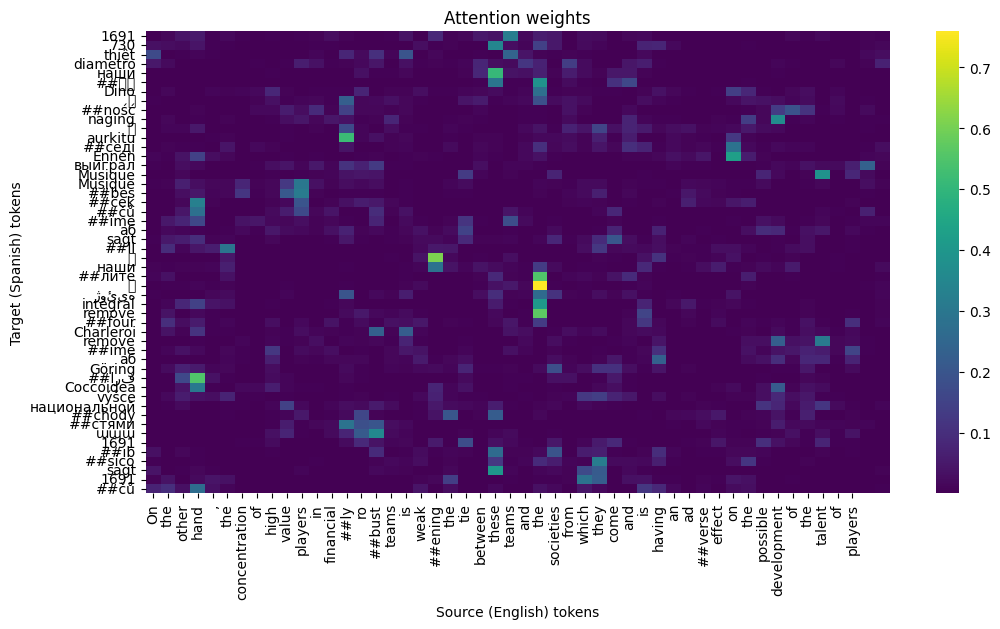

In [18]:
sample_en_sentence = df_test["en"].iloc[1]
print("English:", sample_en_sentence)
print("Reference Spanish:", df_test["es"].iloc[1])
print("\nGenerating translation and visualizing attention...\n")

visualize_attention(model, sample_en_sentence)